In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
a0 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM32.annotation.gtf.gz'
dfg = pd.read_csv(a0, skiprows=5, sep='\t', header=None)
dfg = dfg[dfg[2]=='gene']

#  
gids = dfg[8].str.split(';').apply(lambda x: x[0])
gnms = dfg[8].str.split(';').apply(lambda x: x[2])

gids = gids.str.split('"').apply(lambda x: x[-2])
gnms = gnms.str.split('"').apply(lambda x: x[-2])
gids = gids.str.split('.').apply(lambda x: x[0])

# 
gn2id = pd.Series(gids.values, index=gnms.values)
gid2n = pd.Series(gnms.values, index=gids.values)
gn2id, gid2n

(4933401J01Rik    ENSMUSG00000102693
 Gm26206          ENSMUSG00000064842
 Xkr4             ENSMUSG00000051951
 Gm18956          ENSMUSG00000102851
 Gm37180          ENSMUSG00000103377
                         ...        
 mt-Nd6           ENSMUSG00000064368
 mt-Te            ENSMUSG00000064369
 mt-Cytb          ENSMUSG00000064370
 mt-Tt            ENSMUSG00000064371
 mt-Tp            ENSMUSG00000064372
 Length: 56953, dtype: object,
 ENSMUSG00000102693    4933401J01Rik
 ENSMUSG00000064842          Gm26206
 ENSMUSG00000051951             Xkr4
 ENSMUSG00000102851          Gm18956
 ENSMUSG00000103377          Gm37180
                           ...      
 ENSMUSG00000064368           mt-Nd6
 ENSMUSG00000064369            mt-Te
 ENSMUSG00000064370          mt-Cytb
 ENSMUSG00000064371            mt-Tt
 ENSMUSG00000064372            mt-Tp
 Length: 56953, dtype: object)

In [3]:
%%time
f0   = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_yao23/cell_metadata_with_cluster_annotation_l23_vis_ptlp.csv'
f1 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/allen_yao23/WMB-10Xv3-VIS-raw.h5ad'

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 6.2 µs


In [4]:
meta = pd.read_csv(f0)
adata = sc.read(f1)

In [5]:
adata.X.data

array([91.,  2.,  3., ...,  9., 31., 11.], dtype=float32)

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
print(adata.X.data)
sc.pp.log1p(adata)
print(adata.X.data)

# HVGs
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adatasub = adata[:, adata.var.highly_variable].copy()
print(adatasub.X.data)

# zscore
sc.pp.scale(adatasub, max_value=10)
print(adatasub.X.data)
adatasub

[14.939829    0.3283479   0.49252182 ...  3.30445    11.381995
  4.0387726 ]
[2.768821  0.283936  0.4004672 ... 1.4596493 2.5162435 1.6171625]
[2.768821  0.283936  0.4004672 ... 1.0423261 1.8729426 1.0423261]


AnnData object with n_obs × n_vars = 3800 × 2760
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg'

In [7]:
sc.tl.pca(adatasub, svd_solver='arpack')
pcs = adatasub.obsm['X_pca']
pcs.shape

(3800, 50)

In [8]:
dfviz = pd.DataFrame(pcs[:,:5], index=adatasub.obs.index)
dfviz = dfviz.join(meta.set_index('cell_label'))

In [9]:
meta.iloc[0]

Unnamed: 0                                                   29781
cell_label                                GCACATAGTTTACGAC-447_B06
cell_barcode                                      GCACATAGTTTACGAC
barcoded_cell_sample_label                                 447_B06
library_label                                   L8TX_201204_01_A02
feature_matrix_label                         WMB-10Xv3-Isocortex-1
entity                                                        cell
brain_section_label                                            NaN
library_method                                               10Xv3
region_of_interest_acronym                                VIS-PTLp
donor_label                           Snap25-IRES2-Cre;Ai14-554815
donor_genotype                Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt
donor_sex                                                        F
dataset_label                                            WMB-10Xv3
x                                                        15.19

In [10]:
meta.groupby(['cycle', 'barcoded_cell_sample_label']).size()

cycle  barcoded_cell_sample_label
Dark   444_B04                        831
       445_A05                       1175
Light  441_B01                        724
       447_B06                       1070
dtype: int64

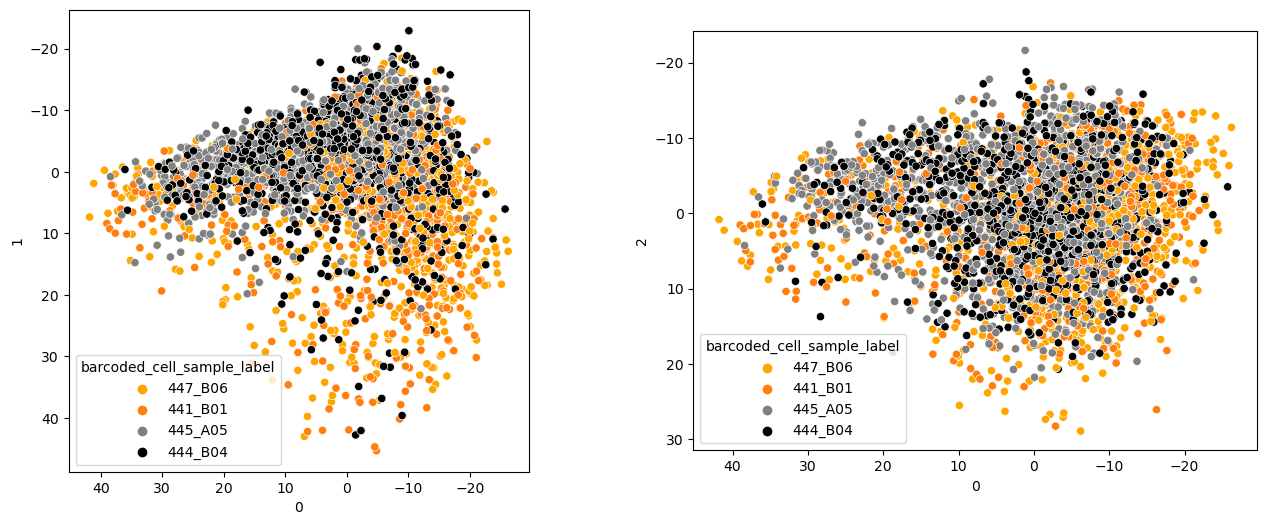

In [29]:
# show replicates

palette = {
    '444_B04': 'k',
    '445_A05': 'gray',
    '441_B01': 'C1',
    '447_B06': 'orange',
}

fig, axs = plt.subplots(1,2,figsize=(8*2,6))
ax = axs[0]
sns.scatterplot(data=dfviz, x=0, y=1, hue='barcoded_cell_sample_label', palette=palette, ax=ax)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')

ax = axs[1]
sns.scatterplot(data=dfviz, x=0, y=2, hue='barcoded_cell_sample_label', palette=palette, ax=ax)
ax.set_aspect('equal')
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()

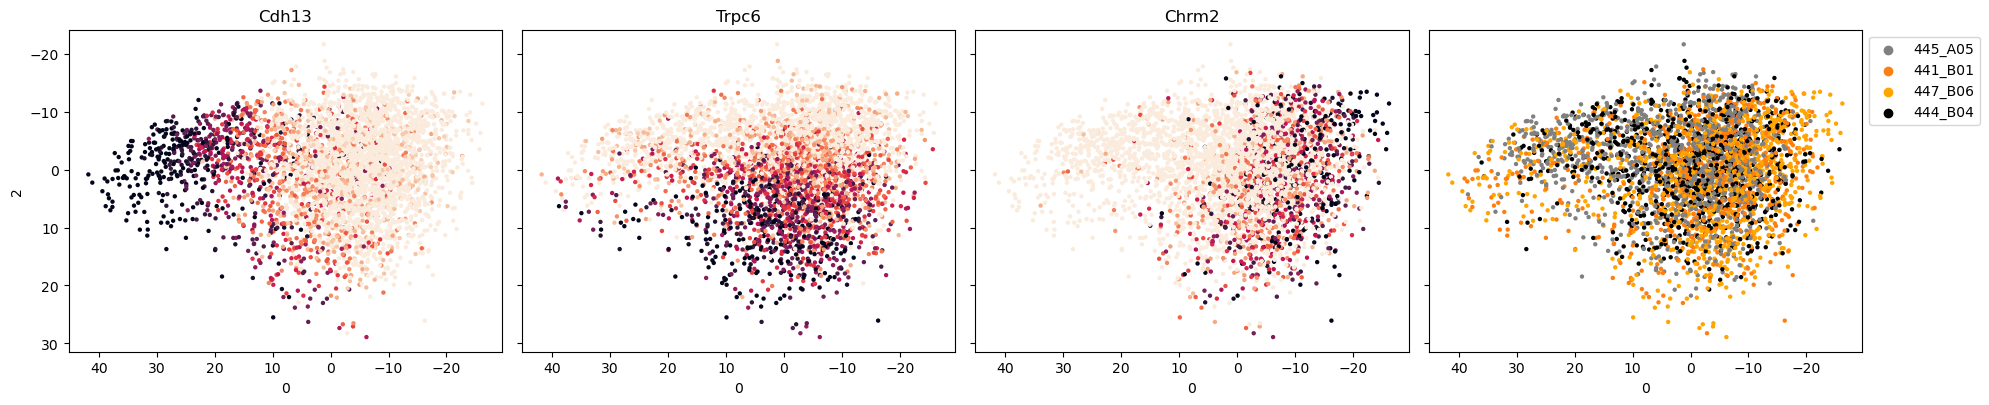

In [30]:

gns = ['Cdh13', 'Sorcs3', 'Chrm2']
gns = ['Cdh13', 'Nptx2', 'Chrm2']
gns = ['Cdh13', 'Trpc6', 'Chrm2']

sx, sy = 0, 2

fig, axs = plt.subplots(1, 4, figsize=(4*5,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=sx, y=sy, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=sx, y=sy, ax=ax, s=10, edgecolor='none', 
                hue='barcoded_cell_sample_label', palette=palette
               )
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

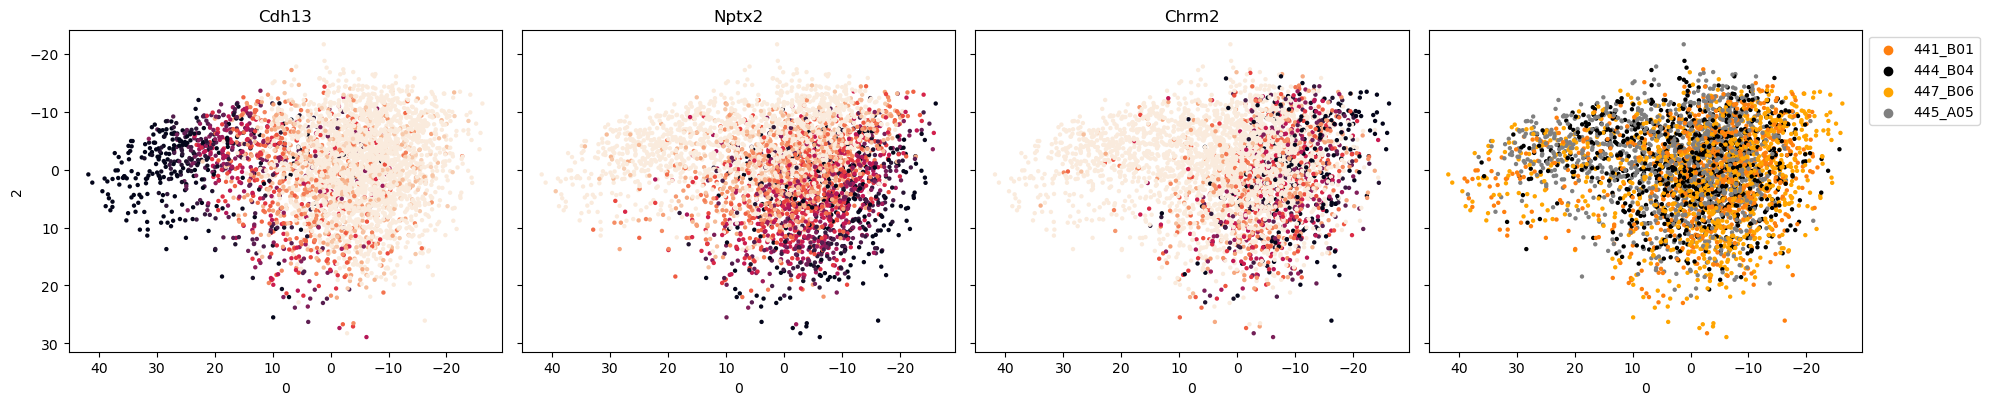

In [13]:

gns = ['Cdh13', 'Sorcs3', 'Chrm2']
gns = ['Cdh13', 'Nptx2', 'Chrm2']

fig, axs = plt.subplots(1, 4, figsize=(4*5,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=2, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=2, ax=ax, s=10, edgecolor='none', 
                hue='barcoded_cell_sample_label', palette=palette
               )
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

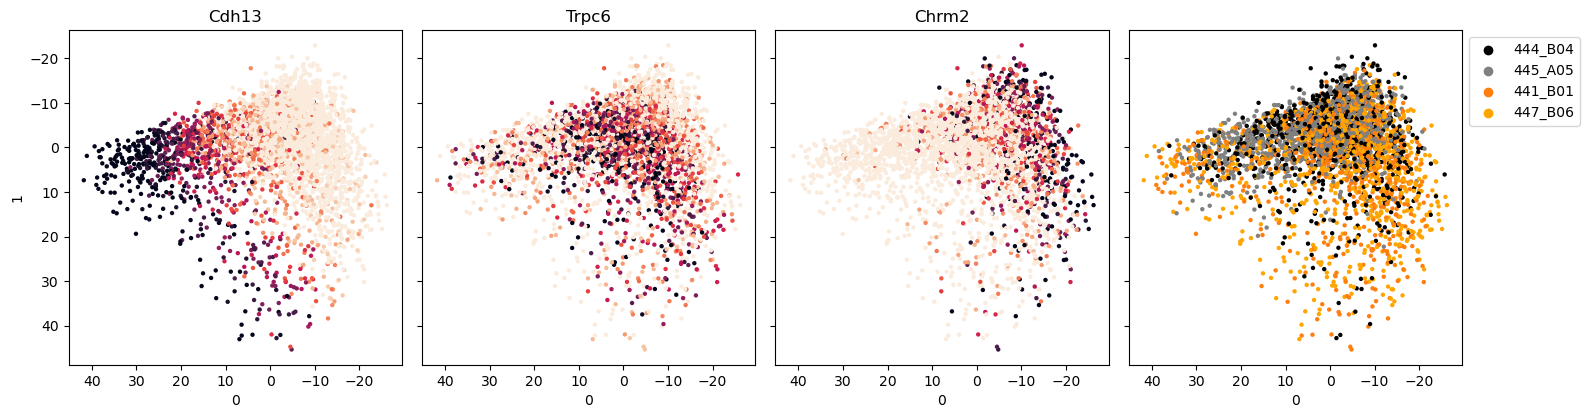

In [14]:

gns = ['Cdh13', 'Sorcs3', 'Chrm2']
gns = ['Cdh13', 'Nptx2', 'Chrm2']
gns = ['Cdh13', 'Trpc6', 'Chrm2']

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=1, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=1, ax=ax, s=10, edgecolor='none', 
                hue='barcoded_cell_sample_label', palette=palette
               )
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

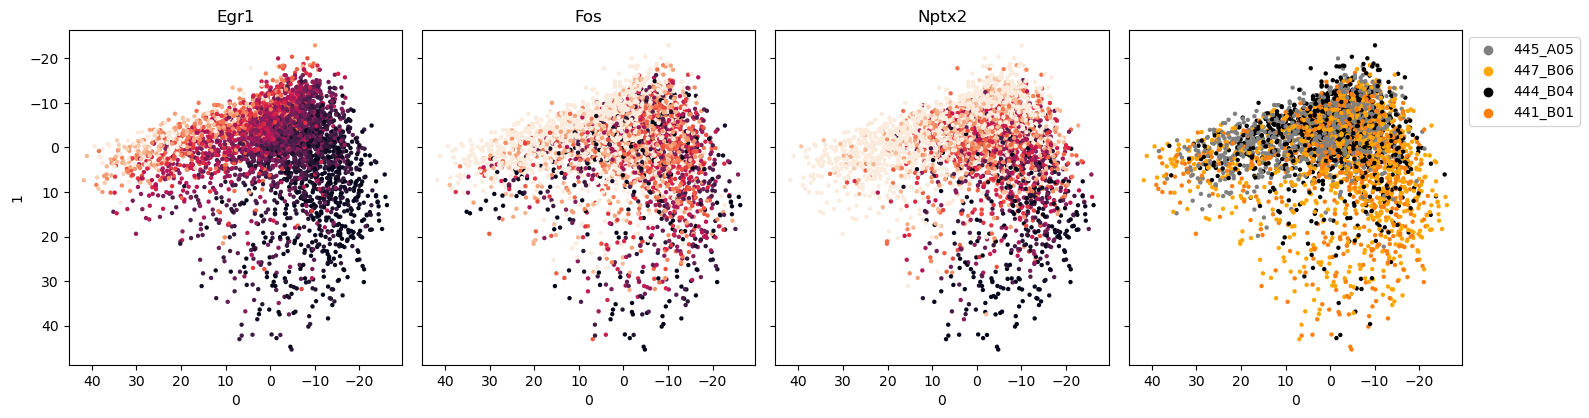

In [15]:


gns = ['Egr1', 'Fos', 'Nptx2']

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=1, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')
    
ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=1, ax=ax, s=10, edgecolor='none', 
                hue='barcoded_cell_sample_label', palette=palette
               )
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

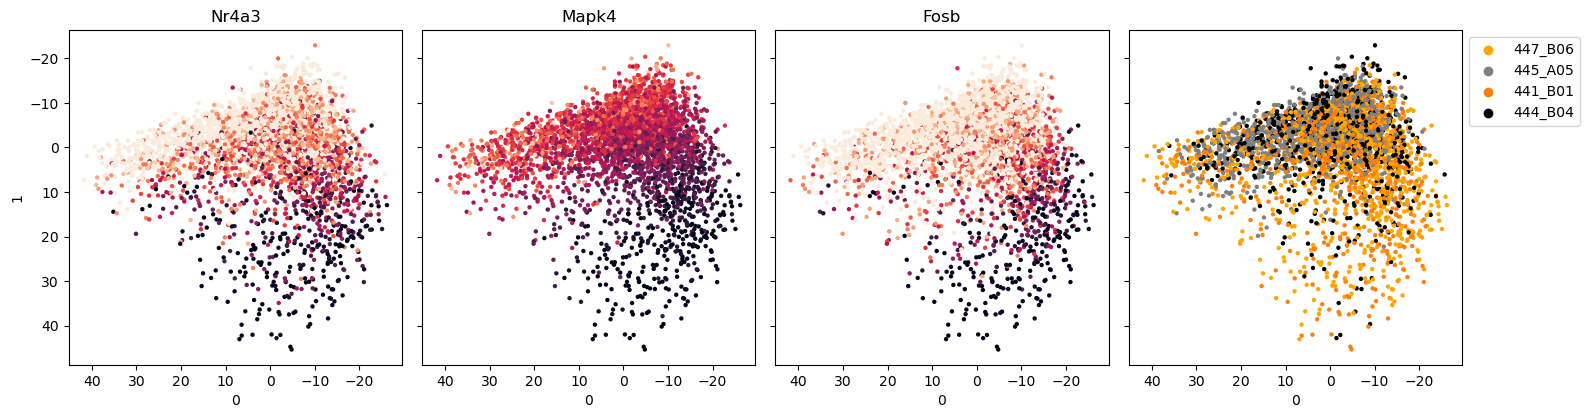

In [149]:
gns = ['Nr4a3', 'Mapk4', 'Fosb',]

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=1, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=1, ax=ax, s=10, edgecolor='none', 
                hue='barcoded_cell_sample_label', palette=palette
               )
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

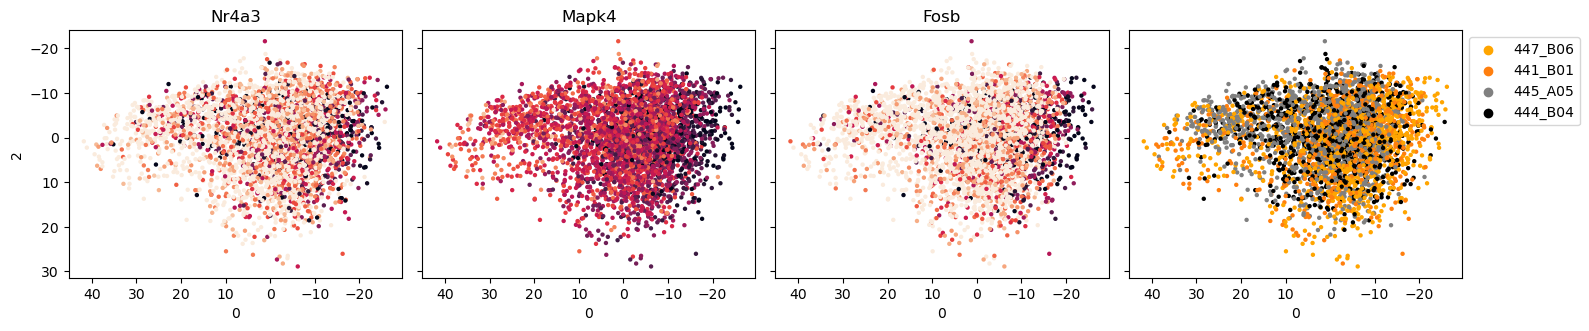

In [150]:
gns = ['Nr4a3', 'Mapk4', 'Fosb',]

fig, axs = plt.subplots(1, 4, figsize=(4*4,1*4), sharex=True, sharey=True)
for ax, gn in zip(axs, gns):
    gid = gn2id.loc[gn]
    gexp = np.array(adata[:,gid].X.todense()).reshape(-1,)
    vmax = np.percentile(gexp, 95)
    sns.scatterplot(data=dfviz, x=0, y=2, c=gexp, vmax=vmax, ax=ax, s=10, edgecolor='none', cmap='rocket_r')
    ax.set_title(gn)
    ax.set_aspect('equal')

ax = axs[3]
sns.scatterplot(data=dfviz.sample(frac=1), x=0, y=2, ax=ax, s=10, edgecolor='none', 
                hue='barcoded_cell_sample_label', palette=palette
               )
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1,1))

ax.invert_xaxis()
ax.invert_yaxis()
fig.tight_layout()
plt.show()

In [41]:
idx_light = (meta.cycle=='Light').values
idx_dark = (meta.cycle=='Dark').values
idx_light

array([ True,  True,  True, ..., False, False, False])

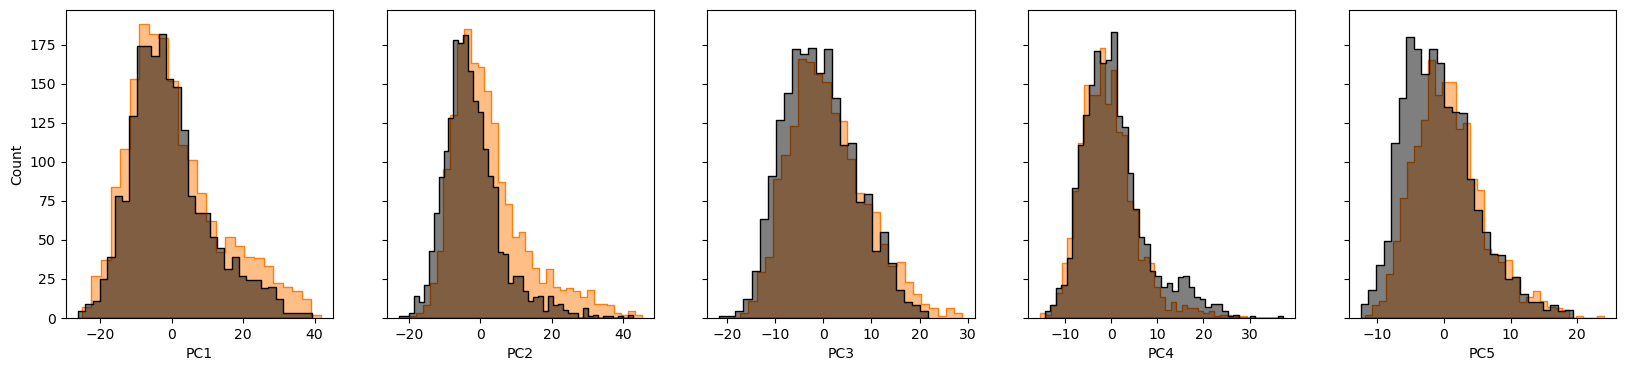

In [56]:
fig, axs = plt.subplots(1,5,figsize=(5*4,1*4), sharey=True)
for i in range(5):
    ax = axs[i]
    sns.histplot(pcs[idx_light][:,i], color='C1', element='step', alpha=0.5, ax=ax)
    sns.histplot(pcs[idx_dark][:,i], color='k', element='step', alpha=0.5, ax=ax)
    ax.set_xlabel(f'PC{i+1}')
plt.show()

# which genes contribute to PC1 the most

In [60]:
adatasub.varm['PCs'].shape

(2760, 50)

In [111]:
# gene loading of top 5 PCs
pcw = np.abs(adatasub.varm['PCs'][:,:5])
# gene ids of top 10 weights
top_gids = adatasub.var.index.values[np.argsort(-pcw, axis=0)[:10]]
# Convert to gene names 
gid2n_dict = gid2n.to_dict()
vfunc = np.vectorize(lambda x: gid2n.get(x, np.nan))
top_gns = vfunc(top_gids)

In [112]:
top_gns.T

array([['Rfx3', 'Cdh13', 'Rph3a', 'Rgs4', 'Scn1b', '6530403H02Rik',
        'Bbln', 'Dnajc21', 'Egr1', 'Cntn5'],
       ['Nr4a3', 'Mapk4', 'Fosb', 'Pim1', 'Sik2', 'Baz1a', 'Ntrk2',
        'Egr4', 'Fosl2', 'Kdm6b'],
       ['Hlf', 'Pcdh15', 'Trpc6', 'Hs6st3', 'Wfs1', 'Sorcs3', 'Npnt',
        'Dgkb', 'Sgcz', 'Kitl'],
       ['Ppia', 'Ndufb9', 'Grm7', 'Prdx5', 'Ubb', 'Mif', 'Atp5d',
        'Cox5b', 'Nme1', 'nan'],
       ['Sox5', 'Grm8', 'Chrm2', 'Kcnip3', 'Cntnap2', 'Ncam2', 'Necab1',
        'Efna5', 'Galnt17', 'Grid2']], dtype='<U13')

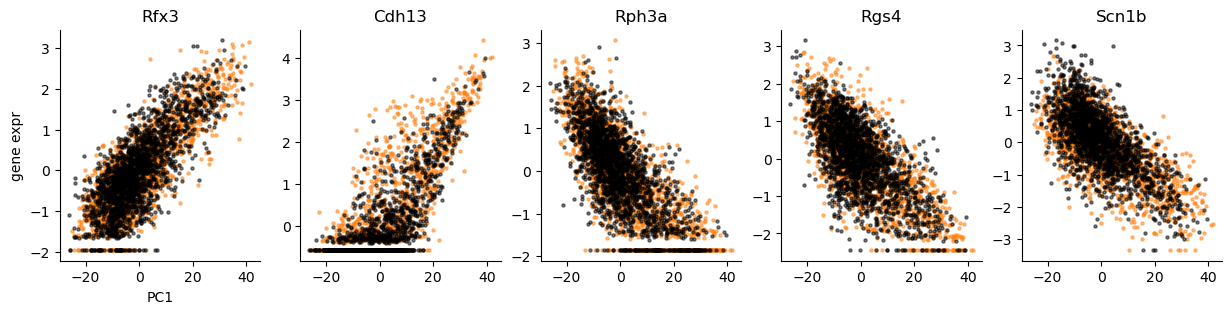

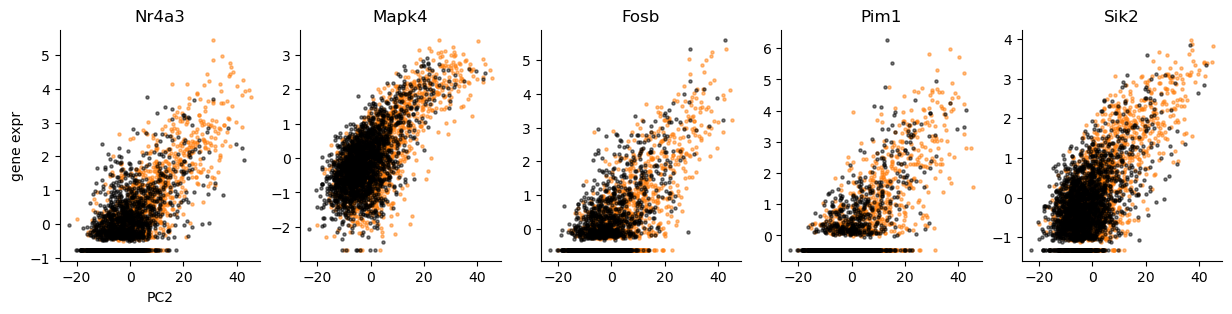

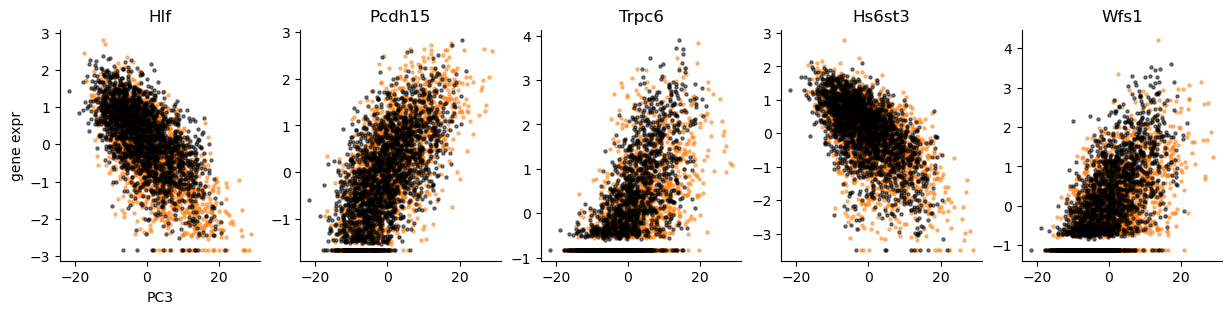

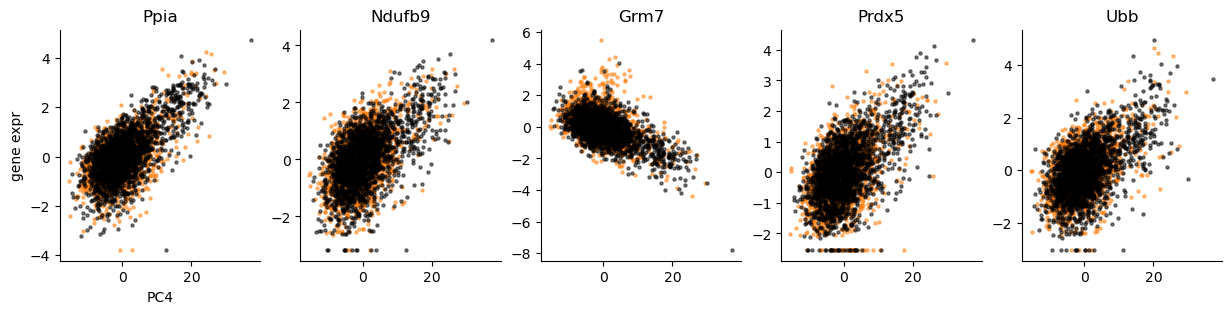

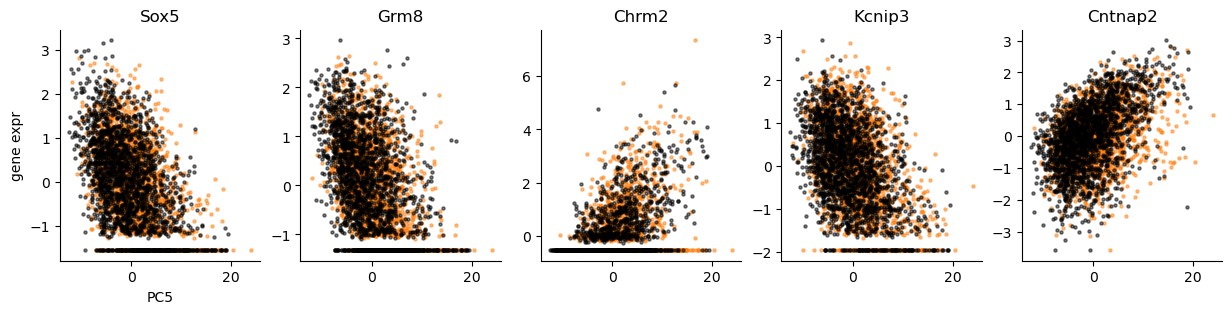

In [136]:

for j in range(5):
    pc_idx = j

    fig, axs = plt.subplots(1,5,figsize=(5*3,1*3), sharex=True)
    for i in range(5):
        ax = axs[i]

        gn_rank = i
        gid = top_gids[gn_rank,pc_idx]
        gn = gid2n.loc[gid]
        gexp = np.array(adatasub[:,gid].X).reshape(-1,)
        ax.scatter(pcs[idx_light,pc_idx], gexp[idx_light], color='C1', alpha=0.5, s=5)
        ax.scatter(pcs[idx_dark,pc_idx], gexp[idx_dark], color='k', alpha=0.5, s=5)
        sns.despine(ax=ax)
        ax.set_title(f'{gn}')
    ax = axs[0]
    ax.set_xlabel(f'PC{pc_idx+1}')
    ax.set_ylabel(f'gene expr')
    plt.show()

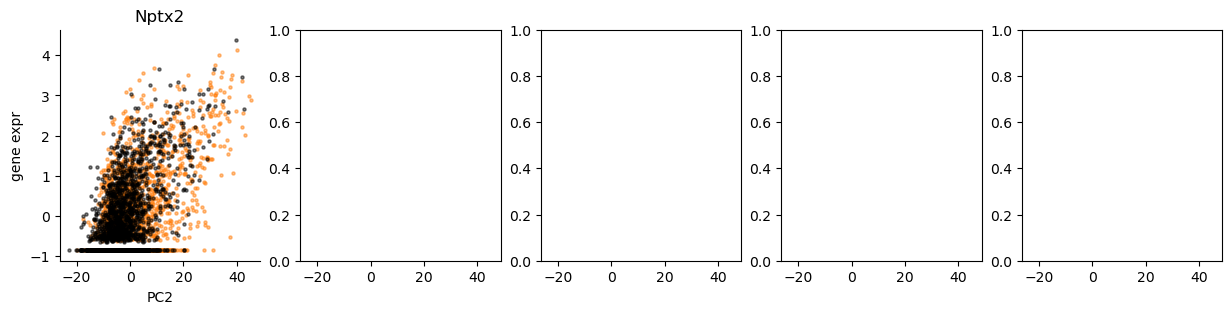

In [146]:
gns = ['Nptx2']
pc_idx = 1

fig, axs = plt.subplots(1,5,figsize=(5*3,1*3), sharex=True)
for i in range(len(gns)):
    ax = axs[i]
    gn = gns[i]
    gid = gn2id.loc[gn]

# gn_rank = i
# gid = top_gids[gn_rank,pc_idx]
# gn = gid2n.loc[gid]
    gexp = np.array(adatasub[:,gid].X).reshape(-1,)
    ax.scatter(pcs[idx_light,pc_idx], gexp[idx_light], color='C1', alpha=0.5, s=5)
    ax.scatter(pcs[idx_dark,pc_idx], gexp[idx_dark], color='k', alpha=0.5, s=5)
    sns.despine(ax=ax)
    ax.set_title(f'{gn}')
    
ax = axs[0]
ax.set_xlabel(f'PC{pc_idx+1}')
ax.set_ylabel(f'gene expr')
plt.show()